# 01 · MNIST dataset

Notebook này chỉ phụ trách tải và xử lý dữ liệu. Kết quả được lưu thành một thư mục dùng chung cho notebook train và notebook test.

Pipeline giống UI Predict:

`28×28 → threshold/binarize đen-trắng → largest component → crop → square → resize theo ANN_DIGIT_SIZE → scale 0..1`

In [1]:
from pathlib import Path
import json
import sys
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd()
while not (PROJECT_ROOT / 'gk' / 'web' / 'backend').exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from gk.web.backend.digits_config import (
    DATASET_DIR, DATASET_META_PATH, PIXEL_COUNT, PIXEL_SIZE,
    RAW_DATASET_PATH, SPLIT_PATH,
)
from gk.web.backend.digits_dataset import load_mnist, normalize_mnist_images

RAW_PATH = RAW_DATASET_PATH
NORMALIZED_PATH = DATASET_DIR / 'mnist_normalized.npz'
META_PATH = DATASET_META_PATH
RANDOM_SEED = 42
DATASET_READY = (
    all(path.exists() for path in (RAW_PATH, NORMALIZED_PATH, META_PATH, SPLIT_PATH))
    and json.loads(META_PATH.read_text(encoding='utf-8')).get('pixel_range') == [0, 1]
)
print('Configured input:', f'{PIXEL_SIZE}x{PIXEL_SIZE} ({PIXEL_COUNT} features)')
print('Project root:', PROJECT_ROOT)
print('Output directory:', DATASET_DIR)

Configured input: 28x28 (784 features)
Project root: /Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02
Output directory: /Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02/gk/web/backend/artifacts/mnist_dataset/28x28


## Tải ảnh thật và normalize

In [2]:
if DATASET_READY:
    raw_data = np.load(RAW_PATH)
    normalized_data = np.load(NORMALIZED_PATH)
    raw_train_images, y_train = raw_data['X_train_images'], raw_data['y_train']
    raw_test_images, y_test = raw_data['X_test_images'], raw_data['y_test']
    X_train_pixels = normalized_data['X_train_pixels'].reshape(len(y_train), -1)
    X_test_pixels = normalized_data['X_test_pixels'].reshape(len(y_test), -1)
    print('Loaded existing prepared dataset:', DATASET_DIR)
else:
    raw_train_images, y_train, raw_test_images, y_test = load_mnist()
    X_train_pixels, X_test_pixels = normalize_mnist_images(raw_train_images, raw_test_images)

print('raw train:', raw_train_images.shape)
print('raw test :', raw_test_images.shape)
X_train_images_normalized = X_train_pixels.reshape(-1, PIXEL_SIZE, PIXEL_SIZE)
X_test_images_normalized = X_test_pixels.reshape(-1, PIXEL_SIZE, PIXEL_SIZE)
print('processed train images:', X_train_images_normalized.shape)
print('processed test images :', X_test_images_normalized.shape)
print('pixel range:', X_train_pixels.min(), X_train_pixels.max())

assert X_train_images_normalized.shape == (60000, PIXEL_SIZE, PIXEL_SIZE)
assert X_test_images_normalized.shape == (10000, PIXEL_SIZE, PIXEL_SIZE)
assert 0 <= X_train_pixels.min() <= X_train_pixels.max() <= 1

Loaded existing prepared dataset: /Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02/gk/web/backend/artifacts/mnist_dataset/28x28
raw train: (60000, 28, 28)
raw test : (10000, 28, 28)
processed train images: (60000, 28, 28)
processed test images : (10000, 28, 28)
pixel range: 0.0 1.0


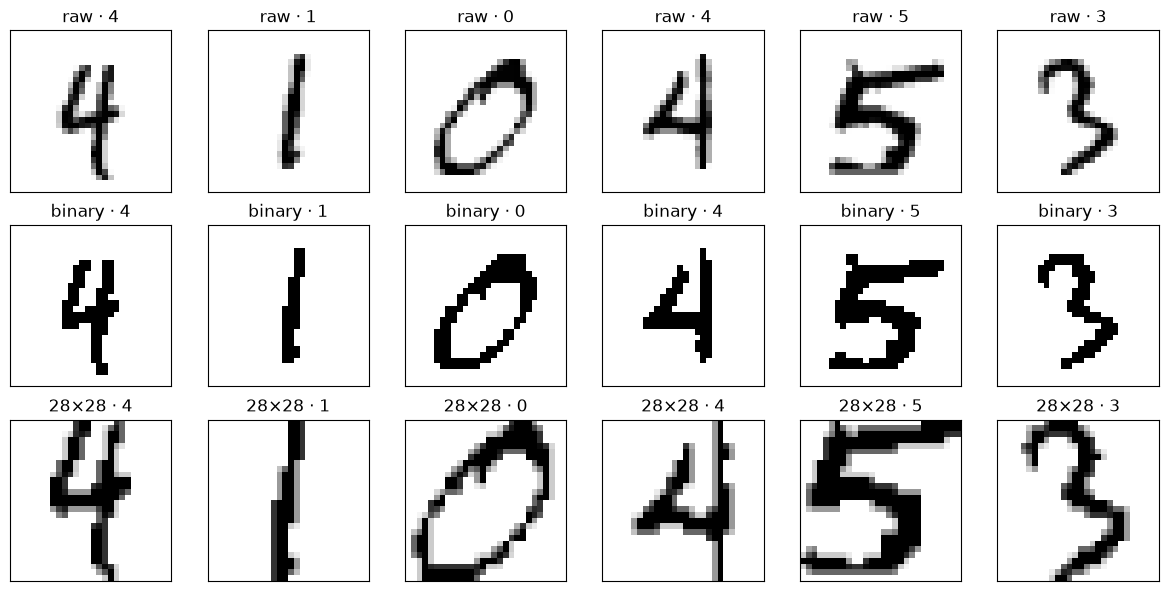

In [3]:
def show_samples(indices):
    fig, axes = plt.subplots(3, len(indices), figsize=(2 * len(indices), 6))
    for column, index in enumerate(indices):
        axes[0, column].imshow(raw_train_images[index], cmap='gray_r', vmin=0, vmax=255)
        axes[0, column].set_title(f'raw · {y_train[index]}')
        threshold = max(1.0, float(raw_train_images[index].max()) * 0.3)
        binary = np.where(raw_train_images[index] >= threshold, 255, 0)
        axes[1, column].imshow(binary, cmap='gray_r', vmin=0, vmax=255)
        axes[1, column].set_title(f'binary · {y_train[index]}')
        axes[2, column].imshow(X_train_images_normalized[index], cmap='gray_r', vmin=0, vmax=1)
        axes[2, column].set_title(f'{PIXEL_SIZE}×{PIXEL_SIZE} · {y_train[index]}')
        for row in range(3):
            axes[row, column].set_xticks([])
            axes[row, column].set_yticks([])
    plt.tight_layout()

sample_indices = np.random.default_rng(RANDOM_SEED).choice(len(y_train), 6, replace=False)
show_samples(sample_indices)

## Xuất thư mục dataset

Thư mục này chứa ảnh raw 28×28, ảnh đã normalize theo ANN_DIGIT_SIZE và các JSON mô tả dataset/split.

In [4]:
if DATASET_READY:
    print('Dataset already exists, no files were rewritten:', DATASET_DIR)
else:
    DATASET_DIR.mkdir(parents=True, exist_ok=True)
    np.savez_compressed(
        RAW_PATH,
        X_train_images=raw_train_images.astype(np.uint8),
        y_train=y_train.astype(np.int64),
        X_test_images=raw_test_images.astype(np.uint8),
        y_test=y_test.astype(np.int64),
    )
    np.savez_compressed(
        NORMALIZED_PATH,
        X_train_pixels=X_train_images_normalized.astype(np.float32),
        y_train=y_train.astype(np.int64),
        X_test_pixels=X_test_images_normalized.astype(np.float32),
        y_test=y_test.astype(np.int64),
    )
    train_indices, validation_indices = train_test_split(
        np.arange(len(y_train)), test_size=0.2, stratify=y_train, random_state=RANDOM_SEED
    )
    SPLIT_PATH.write_text(json.dumps({
        'random_seed': RANDOM_SEED,
        'fit_indices': train_indices.astype(int).tolist(),
        'validation_indices': validation_indices.astype(int).tolist(),
        'test_indices': np.arange(len(y_test)).astype(int).tolist(),
    }, indent=2), encoding='utf-8')
    META_PATH.write_text(json.dumps({
        'name': 'MNIST handwritten digits',
        'source_url': 'https://yann.lecun.com/exdb/mnist/',
        'raw_file': RAW_PATH.name,
        'normalized_file': NORMALIZED_PATH.name,
        'raw_shape': {'train': list(raw_train_images.shape), 'test': list(raw_test_images.shape)},
        'normalized_shape': {'train': list(X_train_images_normalized.shape), 'test': list(X_test_images_normalized.shape)},
        'pixel_range': [0, 1],
        'input_shape': [PIXEL_SIZE, PIXEL_SIZE],
        'pipeline': ['threshold and binarize black/white', 'largest connected component', 'crop', 'center in square canvas', f'area-average resize {PIXEL_SIZE}x{PIXEL_SIZE}', 'scale 0..1'],
    }, indent=2), encoding='utf-8')
    print('Wrote directory:', DATASET_DIR)
    for path in (RAW_PATH, NORMALIZED_PATH, META_PATH, SPLIT_PATH):
        print(f'  {path.name}: {path.stat().st_size / 1024 / 1024:.1f} MB')

Dataset already exists, no files were rewritten: /Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02/gk/web/backend/artifacts/mnist_dataset/28x28


Loaded from local files: /Users/nguyenkz/Documents/code/hoc/CS2207.26.1.CH.02/gk/web/backend/artifacts/mnist_dataset/28x28
raw train: (60000, 28, 28)
normalized train: (60000, 28, 28)
fit/validation split: 48000 12000
pipeline: threshold and binarize black/white → largest connected component → crop → center in square canvas → area-average resize 28x28 → scale 0..1


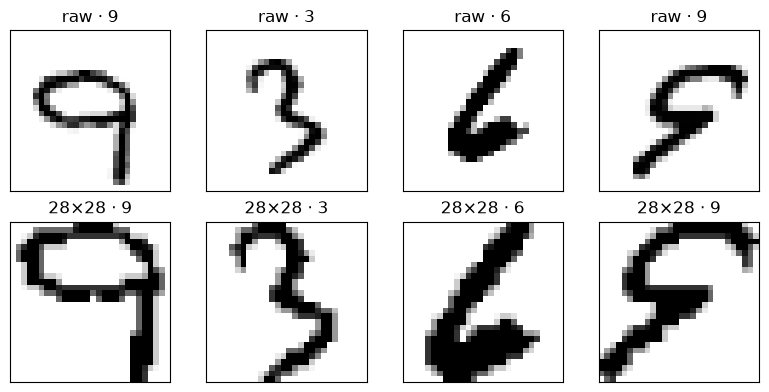

In [5]:
# Load some data from dataset:
# Cell này chỉ đọc lại các file đã tạo ở bước xuất dataset.
raw_saved = np.load(RAW_PATH)
normalized_saved = np.load(NORMALIZED_PATH)
loaded_meta = json.loads(META_PATH.read_text(encoding='utf-8'))
loaded_split = json.loads(SPLIT_PATH.read_text(encoding='utf-8'))

loaded_raw_train = raw_saved['X_train_images']
loaded_y_train = raw_saved['y_train']
loaded_normalized_train = normalized_saved['X_train_pixels']
loaded_normalized_labels = normalized_saved['y_train']

assert loaded_raw_train.shape == (60000, 28, 28)
assert loaded_normalized_train.shape == (60000, PIXEL_SIZE, PIXEL_SIZE)
assert np.array_equal(loaded_y_train, loaded_normalized_labels)
assert loaded_normalized_train.min() >= 0 and loaded_normalized_train.max() <= 1

print('Loaded from local files:', DATASET_DIR)
print('raw train:', loaded_raw_train.shape)
print('normalized train:', loaded_normalized_train.shape)
print('fit/validation split:', len(loaded_split['fit_indices']), len(loaded_split['validation_indices']))
print('pipeline:', ' → '.join(loaded_meta['pipeline']))

sample_indices = np.random.default_rng(RANDOM_SEED).choice(len(loaded_y_train), 4, replace=False)
fig, axes = plt.subplots(2, len(sample_indices), figsize=(8, 4))
for column, index in enumerate(sample_indices):
    axes[0, column].imshow(loaded_raw_train[index], cmap='gray_r', vmin=0, vmax=255)
    axes[0, column].set_title(f'raw · {loaded_y_train[index]}')
    axes[1, column].imshow(loaded_normalized_train[index], cmap='gray_r', vmin=0, vmax=1)
    axes[1, column].set_title(f'{PIXEL_SIZE}×{PIXEL_SIZE} · {loaded_y_train[index]}')
    for row in range(2):
        axes[row, column].set_xticks([])
        axes[row, column].set_yticks([])
plt.tight_layout()
